# Limpieza e integración de datos: felicidad, población e internet (2019)

En este cuaderno preparo un dataset integrado a partir de tres fuentes:

- World Happiness Report 2019 (Kaggle)
- Population, total (Banco Mundial)
- Individuals using the Internet (% of population) (Banco Mundial)

El objetivo es dejar una tabla limpia y documentada para análisis posteriores en el ámbito de salud y bienestar.

In [1]:
# Instalación silenciosa de missingno (sin ensuciar la salida)
%%capture
!pip install missingno

### Importación de librerías

In [23]:
# Librerías para el análisis
import pandas as pd        # Manipulación de datos
import numpy as np         # Operaciones numéricas

# Visualización
import matplotlib.pyplot as plt  # Gráficos base
import seaborn as sns            # Visualización estadística
import missingno as msno         # Exploración de nulos
import plotly.express as px      # Gráficos interactivos

# Trabajo con Google Drive
from google.colab import drive

### Conexión con Google Drive y revisión de archivos raw

In [3]:
# Montamos Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
# Estilo general de los gráficos: fondo claro y rejilla suave
sns.set_theme(style="whitegrid")
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

### Carga de los datasets originales (versión raw)

In [4]:
# Carga de las tres fuentes originales (felicidad, población, internet)
df_happiness = pd.read_csv('/content/drive/MyDrive/01_raw_data/world_happiness_2019_kaggle_raw.csv')

df_population = pd.read_csv(
    '/content/drive/MyDrive/01_raw_data/population_worldbank_raw.csv',
    skiprows=4  # salto de metadatos del Banco Mundial
)

df_internet = pd.read_csv(
    '/content/drive/MyDrive/01_raw_data/internet_users_worldbank_raw.csv',
    skiprows=4  # salto de metadatos del Banco Mundial
)

# Aseguramos que son DataFrames
df_happiness = pd.DataFrame(df_happiness)
df_population = pd.DataFrame(df_population)
df_internet   = pd.DataFrame(df_internet)


### Exploración rápida: tamaño y primeras filas

In [5]:
# Resumen básico de cada dataset raw
datasets_raw = {
    "Happiness 2019": df_happiness,
    "Population (World Bank)": df_population,
    "Internet users (World Bank)": df_internet
}

for name, df in datasets_raw.items():
    print(f"\n--- {name} ---")
    print("Shape (filas, columnas):", df.shape)
    display(df.head(3))


--- Happiness 2019 ---
Shape (filas, columnas): (156, 9)


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341



--- Population (World Bank) ---
Shape (filas, columnas): (266, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN



--- Internet users (World Bank) ---
Shape (filas, columnas): (266, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,93.5425,97.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,15.8000,17.30,19.6,22.4,25.0000,28.2000,30.2000,32.4000,35.0,NaN
2,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0000,13.50,16.8,17.6,17.0485,16.5143,17.1917,17.7089,NaN,NaN


### Diagnóstico inicial: tipos de datos y valores nulos

In [6]:
# Info y nulos por columna en cada tabla
for name, df in datasets_raw.items():
    print(f"\n=== {name} ===")
    df.info()
    print("\nNulos por columna:")
    print(df.isna().sum().sort_values(ascending=False))
    print("-" * 40)


=== Happiness 2019 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB

Nulos por columna:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Soci

### Filtro al año 2019 para población e internet

In [7]:
# Seleccionamos solo columnas relevantes para 2019
pop_2019 = df_population[['Country Name', 'Country Code', '2019']].copy()
pop_2019 = pop_2019.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    '2019': 'population_2019'
})

internet_2019 = df_internet[['Country Name', 'Country Code', '2019']].copy()
internet_2019 = internet_2019.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    '2019': 'internet_users_pct_2019'
})

### Comprobación de las tablas alineadas a 2019

In [8]:
# Check de estructura, tipos y nulos en las tablas alineadas a 2019
datasets_2019 = {
    "Happiness 2019": df_happiness,
    "Population 2019": pop_2019,
    "Internet users 2019": internet_2019
}

for name, df in datasets_2019.items():
    print(f"\n=== {name} ===")
    print("Shape (filas, columnas):", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    print(df.isna().sum())
    print("-" * 40)


=== Happiness 2019 ===
Shape (filas, columnas): (156, 9)

Tipos de datos:
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Valores nulos por columna:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64
----------------------------------------

=== Population 2019 ===
Shape (filas, columnas): (266, 3)

Tipos de datos:
country             object
country_code        object
population_2019    float64
dtype:

### Visualización de valores faltantes con *missingno*

Uso una vista tipo matriz para ver el patrón de nulos por fila y un gráfico de barras para resumir cuántos datos faltan en cada columna de 2019.  
La idea es detectar rápidamente tablas completas, columnas problemáticas y patrones de ausencia de datos.


Mapa de nulos – Happiness 2019


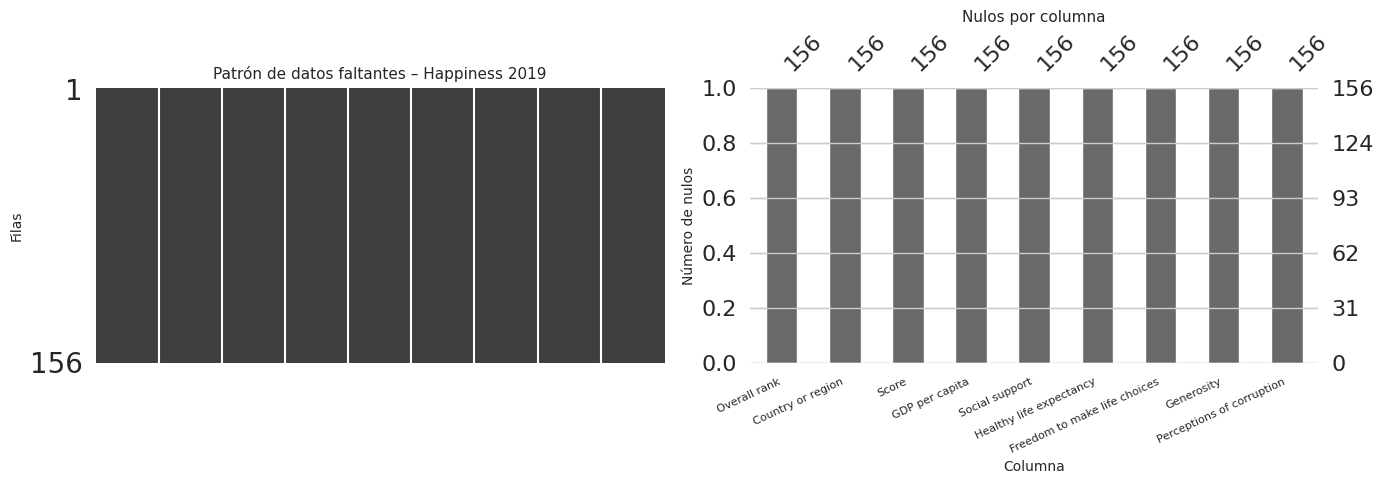


Mapa de nulos – Population 2019


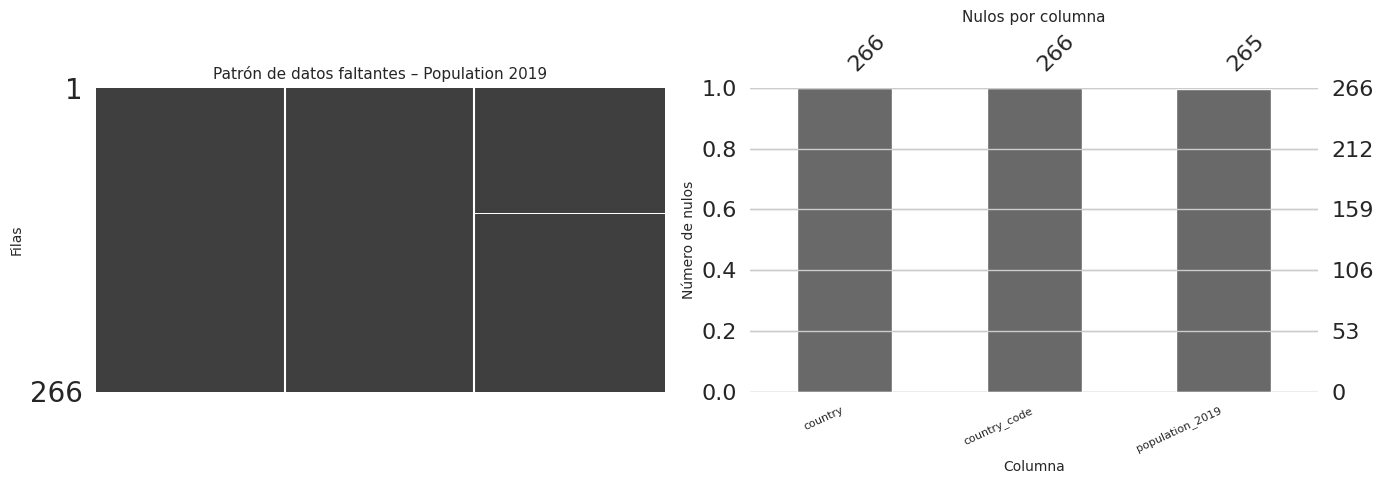


Mapa de nulos – Internet users 2019


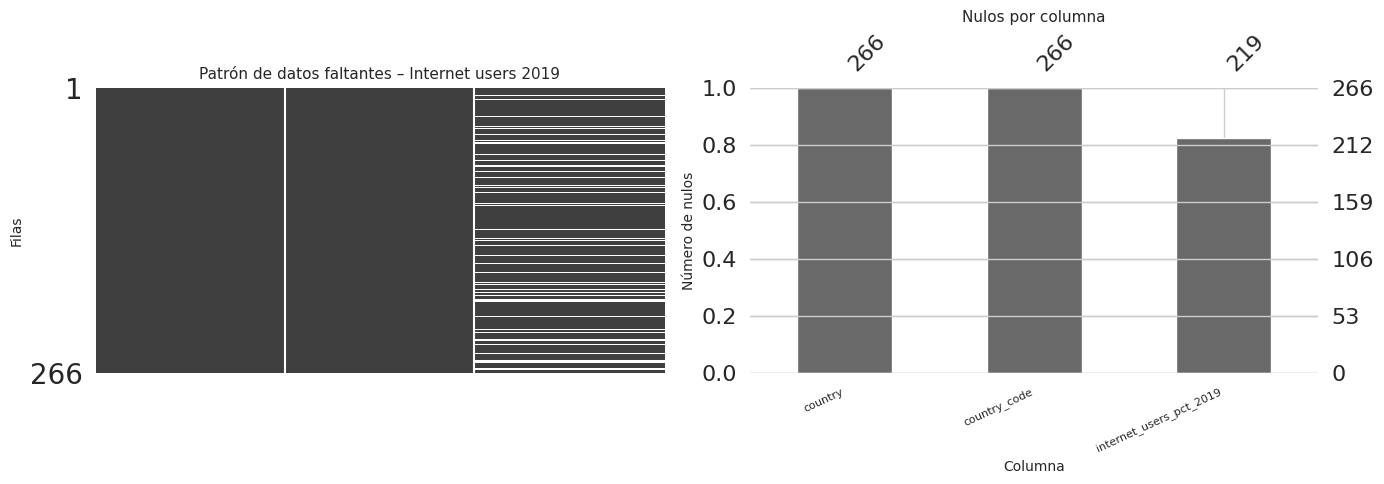

In [48]:
### Visualización de valores faltantes con missingno

for name, df in datasets_2019.items():
    print(f"\nMapa de nulos – {name}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Patrón de nulos (matriz) ---
    msno.matrix(
        df,
        ax=axes[0],
        sparkline=False
    )
    axes[0].set_title(f"Patrón de datos faltantes – {name}")
    axes[0].set_ylabel("Filas")
    axes[0].set_xlabel("")  # evitamos texto extra abajo

    # oculto las etiquetas del eje X en la matriz para que no saturen
    axes[0].tick_params(axis="x", labelbottom=False)
    axes[0].set_xticks([])

    # --- Barras por columna ---
    msno.bar(df, ax=axes[1])
    axes[1].set_title("Nulos por columna")
    axes[1].set_xlabel("Columna")
    axes[1].set_ylabel("Número de nulos")

    # rotación suave, legible
    axes[1].tick_params(axis="x", labelrotation=25, labelsize=8)

    plt.tight_layout()
    plt.show()

### Copias de trabajo para limpieza

In [10]:
# Copias de trabajo para no tocar las tablas raw
happiness_clean   = df_happiness.copy()
pop_2019_clean    = pop_2019.copy()
internet_2019_clean = internet_2019.copy()

### Tratamiento inicial de valores ausentes

In [11]:
# Población: elimino el único país sin dato
pop_2019_clean = pop_2019_clean.dropna(subset=['population_2019'])

# Internet: marco si hay dato disponible o no
internet_2019_clean['internet_data_available'] = ~internet_2019_clean['internet_users_pct_2019'].isna()

### Normalización de nombres de país y tipos de dato

In [12]:
# Renombramos columna de país en felicidad para alinearla
happiness_clean = happiness_clean.rename(columns={'Country or region': 'country'})

# Limpieza básica de texto en nombres de país
for df in [happiness_clean, pop_2019_clean, internet_2019_clean]:
    df['country'] = df['country'].astype(str).str.strip()

# Aseguro tipo entero tolerante a nulos en población
pop_2019_clean['population_2019'] = pop_2019_clean['population_2019'].astype('Int64')

### Integración de felicidad, población e internet en una tabla única

In [13]:
# Unión de felicidad con población
happiness_pop_2019 = happiness_clean.merge(
    pop_2019_clean[['country', 'population_2019', 'country_code']],
    on='country',
    how='left'
)

# Unión posterior con internet
full_2019 = happiness_pop_2019.merge(
    internet_2019_clean[['country', 'internet_users_pct_2019', 'internet_data_available']],
    on='country',
    how='left'
)

full_2019.head()

,Overall rank,country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,population_2019,country_code,internet_users_pct_2019,internet_data_available
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,5521606,FIN,89.6074,True
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,5814422,DNK,98.0464,True
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,5347896,NOR,98.0000,True
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,360563,ISL,99.5049,True
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,17344874,NLD,93.2886,True


### Revisión de la tabla integrada (estructura y nulos)

In [14]:
print("Dimensiones tabla final:", full_2019.shape)
full_2019.info()
print("\nNulos por columna en full_2019:")
print(full_2019.isna().sum())

Dimensiones tabla final: (156, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   country                       156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
 9   population_2019               132 non-null    Int64  
 10  country_code                  132 non-null    object 
 11  internet_users_pct_2019       127 non-null    float64
 12  internet_data_available      

### Distribución de las variables principales

Estos histogramas muestran cómo se reparten la felicidad, la población y el uso de internet entre países.  
El objetivo es ver si la mayoría de países se agrupan en ciertos rangos o si la distribución está muy dispersa.

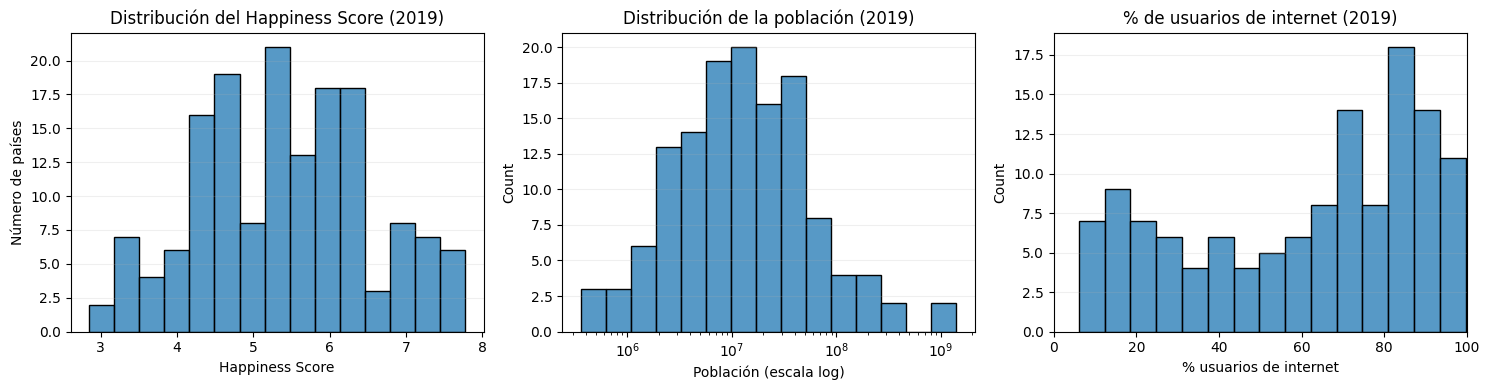

In [38]:
# Histogramas de variables clave en la tabla integrada
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# Felicidad
sns.histplot(
    full_2019["Score"],
    bins=15,
    ax=axes[0],
    edgecolor="black"
)
axes[0].set_title("Distribución del Happiness Score (2019)")
axes[0].set_xlabel("Happiness Score")
axes[0].set_ylabel("Número de países")

# Población (escala logarítmica para hacerla más legible)
sns.histplot(
    full_2019["population_2019"],
    bins=15,
    ax=axes[1],
    edgecolor="black",
    log_scale=True
)
axes[1].set_title("Distribución de la población (2019)")
axes[1].set_xlabel("Población (escala log)")

# Uso de internet (recorto a 0–100 por claridad)
sns.histplot(
    full_2019["internet_users_pct_2019"],
    bins=15,
    ax=axes[2],
    edgecolor="black"
)
axes[2].set_title("% de usuarios de internet (2019)")
axes[2].set_xlabel("% usuarios de internet")
axes[2].set_xlim(0, 100)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Top 10 países por felicidad, población y acceso a internet

En los siguientes gráficos muestro los 10 países con valores más altos en cada indicador.


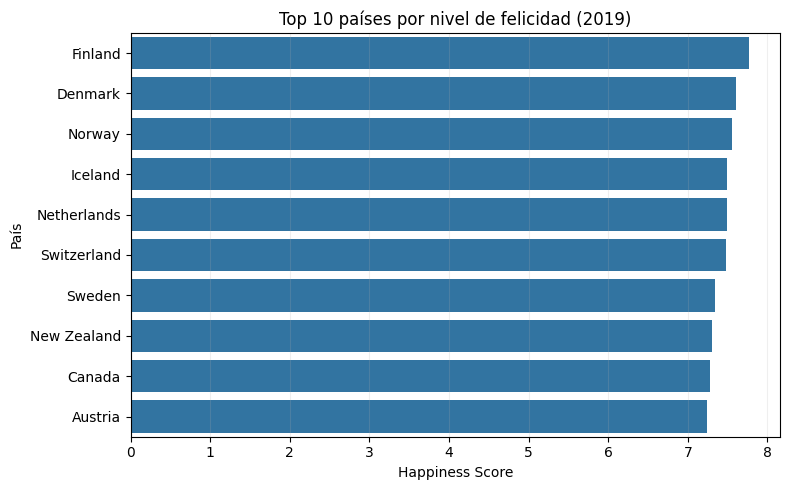

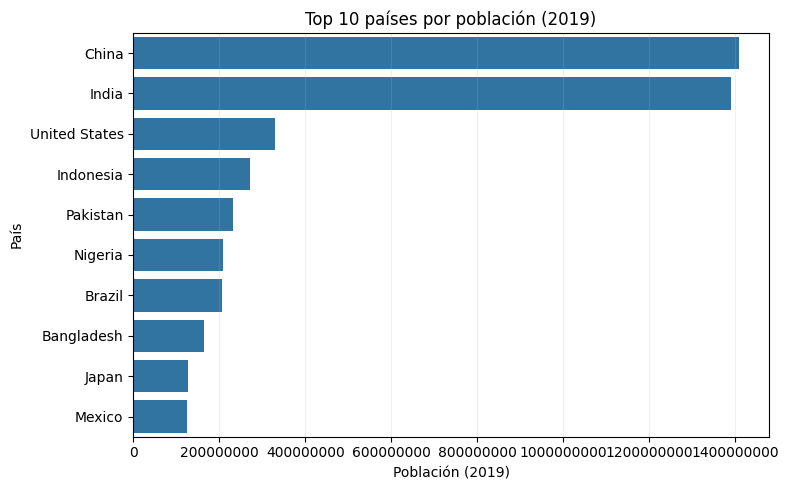

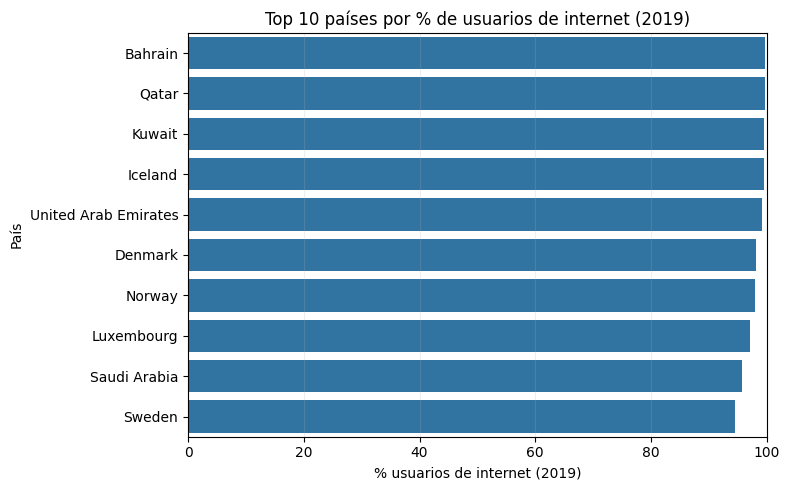

In [36]:
# Top 10 por felicidad
top_happy = full_2019.sort_values("Score", ascending=False).head(10)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=top_happy,
    x="Score",
    y="country"
)
ax.set_title("Top 10 países por nivel de felicidad (2019)")
ax.set_xlabel("Happiness Score")
ax.set_ylabel("País")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Top 10 por población
top_pop = full_2019.sort_values("population_2019", ascending=False).head(10)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=top_pop,
    x="population_2019",
    y="country"
)
ax.set_title("Top 10 países por población (2019)")
ax.set_xlabel("Población (2019)")
ax.set_ylabel("País")
ax.ticklabel_format(style="plain", axis="x")  # sin notación científica
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Top 10 por % usuarios de internet
top_internet = full_2019.sort_values("internet_users_pct_2019", ascending=False).head(10)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=top_internet,
    x="internet_users_pct_2019",
    y="country"
)
ax.set_title("Top 10 países por % de usuarios de internet (2019)")
ax.set_xlabel("% usuarios de internet (2019)")
ax.set_ylabel("País")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Matriz de correlación entre indicadores (2019)

En este gráfico resumo la relación lineal entre las variables numéricas.  
Los valores van de -1 (relación negativa fuerte) a 1 (relación positiva fuerte).  
Los números aparecen escritos en cada celda para que no sea necesario depender solo del color.

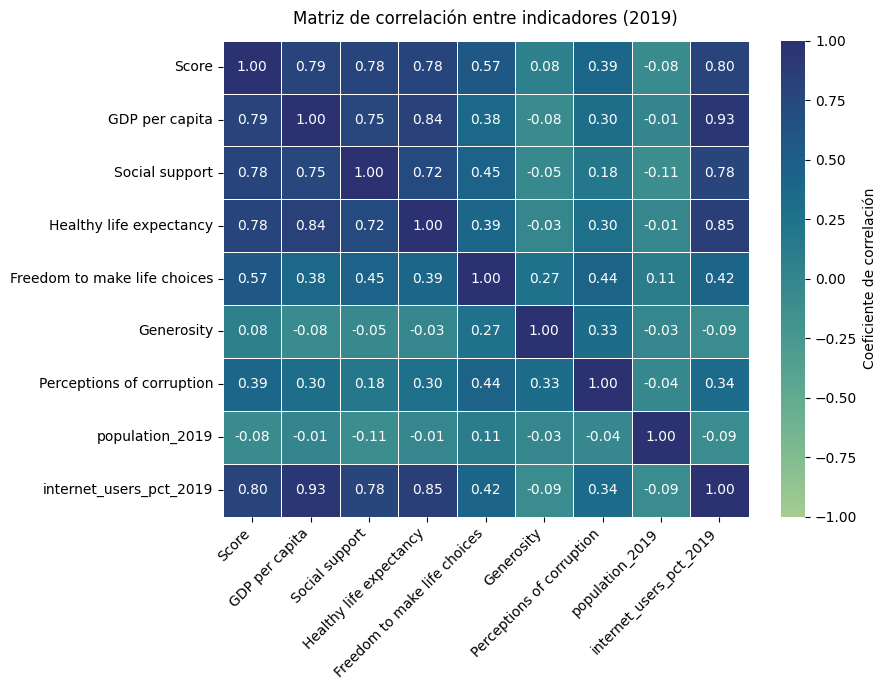

In [30]:
# Matriz de correlación con foco en legibilidad y accesibilidad
numeric_cols = [
    "Score",
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption",
    "population_2019",
    "internet_users_pct_2019",
]

corr = full_2019[numeric_cols].corr()

plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    corr,
    annot=True,          # muestra el valor numérico
    fmt=".2f",
    cmap="crest",        # escala perceptualmente uniforme y apta para daltónicos
    vmin=-1,
    vmax=1,
    linewidths=0.5,      # separadores suaves entre celdas
    linecolor="white",
    cbar_kws={"label": "Coeficiente de correlación"},
)

ax.set_title("Matriz de correlación entre indicadores (2019)", pad=12)

# Etiquetas ligeramente inclinadas para que no se solapen pero sigan siendo legibles
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Relaciones entre felicidad, economía, salud y acceso digital

Aquí reviso relaciones lineales básicas entre la puntuación de felicidad y tres variables:  
PIB per cápita, esperanza de vida saludable y porcentaje de usuarios de internet.  
Cada punto es un país; la línea marca la tendencia general.

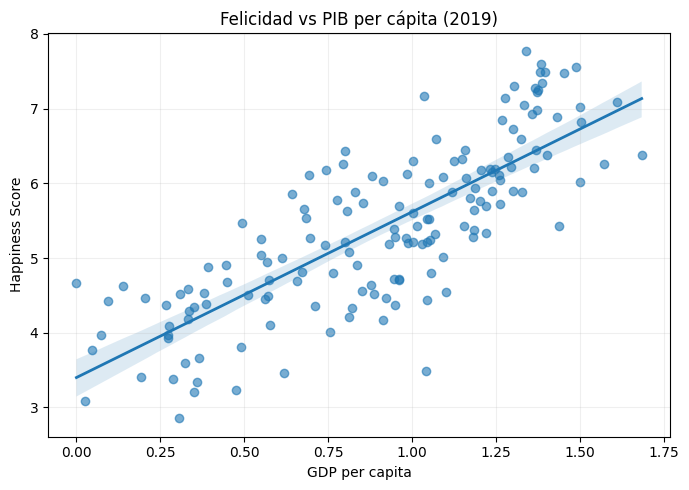

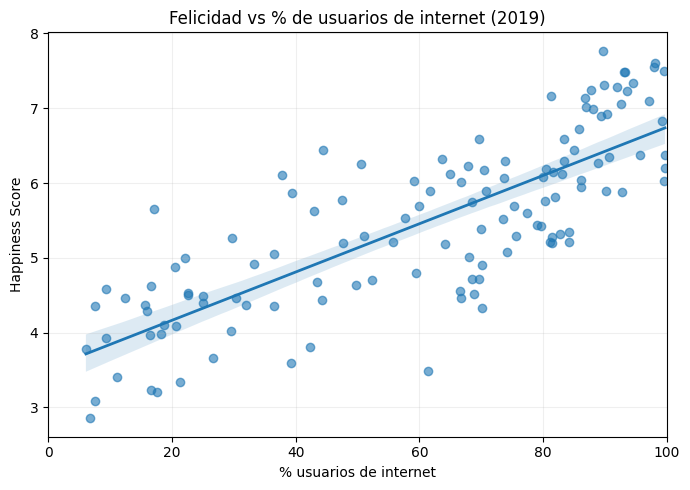

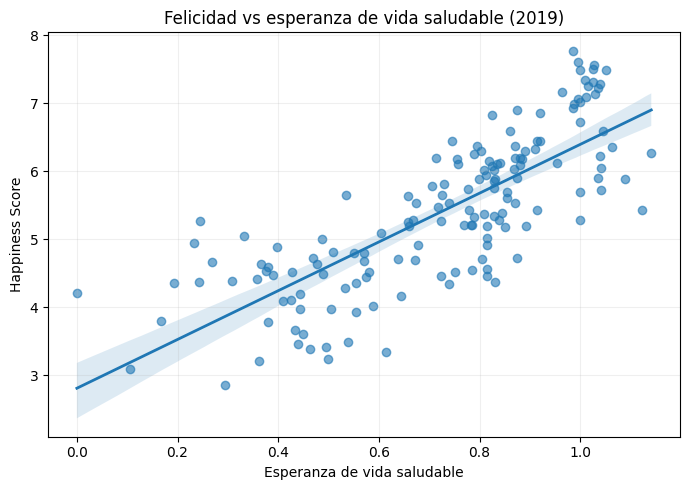

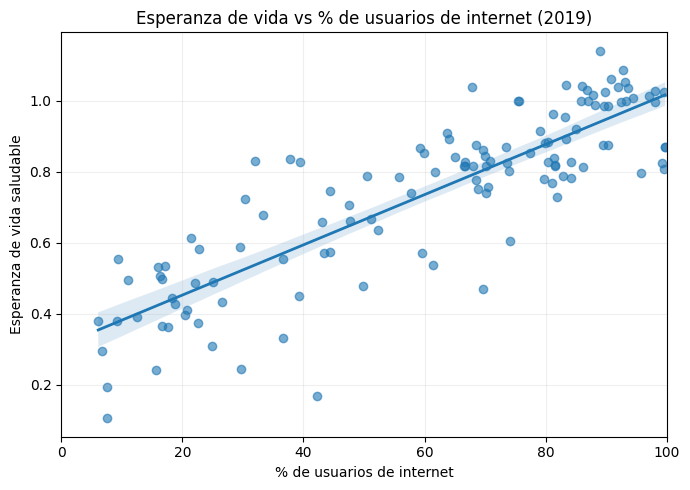

In [34]:
# Felicidad vs PIB per cápita
plt.figure(figsize=(7, 5))
sns.regplot(
    data=full_2019,
    x="GDP per capita",
    y="Score",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.title("Felicidad vs PIB per cápita (2019)")
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.grid(axis="both", alpha=0.2)
plt.tight_layout()
plt.show()

# Felicidad vs % de usuarios de internet
plt.figure(figsize=(7, 5))
sns.regplot(
    data=full_2019,
    x="internet_users_pct_2019",
    y="Score",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.title("Felicidad vs % de usuarios de internet (2019)")
plt.xlabel("% usuarios de internet")
plt.ylabel("Happiness Score")
plt.xlim(0, 100)
plt.grid(axis="both", alpha=0.2)
plt.tight_layout()
plt.show()

# Felicidad vs esperanza de vida saludable
plt.figure(figsize=(7, 5))
sns.regplot(
    data=full_2019,
    x="Healthy life expectancy",
    y="Score",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.title("Felicidad vs esperanza de vida saludable (2019)")
plt.xlabel("Esperanza de vida saludable")
plt.ylabel("Happiness Score")
plt.grid(axis="both", alpha=0.2)
plt.tight_layout()
plt.show()

# Esperanza de vida vs % de usuarios de internet
plt.figure(figsize=(7, 5))
sns.regplot(
    data=full_2019,
    x="internet_users_pct_2019",
    y="Healthy life expectancy",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.title("Esperanza de vida vs % de usuarios de internet (2019)")
plt.xlabel("% de usuarios de internet")
plt.ylabel("Esperanza de vida saludable")
plt.xlim(0, 100)
plt.grid(axis="both", alpha=0.2)
plt.tight_layout()
plt.show()

### Mapa mundial de felicidad (2019)

In [32]:
# Copia para el mapa
map_df = full_2019.copy()

fig = px.choropleth(
    map_df,
    locations="country_code",
    color="Score",
    hover_name="country",
    color_continuous_scale="Viridis",  # escala apta para daltónicos
    range_color=(map_df["Score"].min(), map_df["Score"].max()),
    title="Puntuación de felicidad por país (2019)"
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Happiness Score"
    )
)

fig.show()

### Clasificación de la felicidad en niveles

En el Proyecto 1 trabajé con la idea de analizar valores atípicos dentro de distintas categorías. Ese enfoque me resultó útil para entender mejor la estructura interna de un dataset, así que aquí aplico la misma lógica pero adaptada a este caso.

Para ello, agrupo los países en niveles de felicidad (baja, media, alta y muy alta) con el objetivo de comprobar si la presencia de outliers en el acceso digital cambia según el nivel de bienestar. Esta clasificación me permite comparar grupos más homogéneos y detectar comportamientos extremos dentro de cada uno.

In [24]:
# Clasifico la felicidad en niveles para analizar outliers por grupos
bins_score = [0, 4, 6, 7.5, full_2019["Score"].max()]
labels_score = ["baja", "media", "alta", "muy_alta"]

full_2019["happiness_level"] = pd.cut(
    full_2019["Score"],
    bins=bins_score,
    labels=labels_score,
    right=False
)

full_2019["happiness_level"].value_counts()

,count
happiness_level,
media,88
alta,49
baja,16
muy_alta,2


### Detección básica de valores atípicos (IQR)

In [20]:
# Revisión simple de posibles outliers en variables numéricas clave
numeric_cols_out = ['Score', 'population_2019', 'internet_users_pct_2019']

for col in numeric_cols_out:
    serie = full_2019[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((serie < lower) | (serie > upper)).sum()

    print(f"\nColumna: {col}")
    print(f"  Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
    print(f"  Límite inferior = {lower:.2f}, superior = {upper:.2f}")
    print(f"  Nº de posibles outliers: {n_outliers}")


Columna: Score
  Q1 = 4.54, Q3 = 6.18, IQR = 1.64
  Límite inferior = 2.08, superior = 8.64
  Nº de posibles outliers: 0

Columna: population_2019
  Q1 = 4968517.75, Q3 = 33083674.75, IQR = 28115157.00
  Límite inferior = -37204217.75, superior = 75256410.25
  Nº de posibles outliers: 13

Columna: internet_users_pct_2019
  Q1 = 36.54, Q3 = 84.15, IQR = 47.61
  Límite inferior = -34.88, superior = 155.57
  Nº de posibles outliers: 0


### Outliers por nivel de felicidad con la regla de Tukey

Además del análisis global, me interesa ver cómo se comportan los valores atípicos de acceso digital dentro de cada nivel de felicidad.

Para ello, aplico la regla de Tukey (Q1, Q3, IQR) al porcentaje de usuarios de internet, pero calculada por grupos de felicidad. De esta forma puedo detectar qué países se salen del patrón de su propio grupo.

In [25]:
# Detección de outliers en % de usuarios de internet según nivel de felicidad
categories = full_2019["happiness_level"].dropna().unique()

for cat in categories:
    subset = full_2019[full_2019["happiness_level"] == cat].copy()
    serie = subset["internet_users_pct_2019"].dropna()

    if serie.empty:
        print(f"\nNivel de felicidad: {cat} (sin datos de internet)")
        continue

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    # Límites de Tukey
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Outliers detectados
    outliers = subset[
        (subset["internet_users_pct_2019"] < lower) |
        (subset["internet_users_pct_2019"] > upper)
    ]

    print(f"\nNivel de felicidad: {cat}")
    print(f"    Q1: {q1:.2f}")
    print(f"    Q3: {q3:.2f}")
    print(f"    IQR: {iqr:.2f}")
    print(f"    Límite inferior: {lower:.2f}")
    print(f"    Límite superior: {upper:.2f}")
    print(f"    Outliers detectados: {len(outliers)}")


Nivel de felicidad: muy_alta
    Q1: 98.01
    Q3: 98.03
    IQR: 0.02
    Límite inferior: 97.98
    Límite superior: 98.07
    Outliers detectados: 0

Nivel de felicidad: alta
    Q1: 73.85
    Q3: 92.67
    IQR: 18.83
    Límite inferior: 45.61
    Límite superior: 120.91
    Outliers detectados: 2

Nivel de felicidad: media
    Q1: 29.88
    Q3: 74.00
    IQR: 44.13
    Límite inferior: -36.32
    Límite superior: 140.20
    Outliers detectados: 0

Nivel de felicidad: baja
    Q1: 9.80
    Q3: 25.28
    IQR: 15.48
    Límite inferior: -13.42
    Límite superior: 48.50
    Outliers detectados: 1


### Boxplot de acceso digital por nivel de felicidad

Para visualizar mejor cómo se distribuye el acceso digital dentro de cada grupo de felicidad, utilizo un boxplot. Esto permite ver la mediana, la dispersión y los posibles outliers de cada nivel en una sola gráfica.

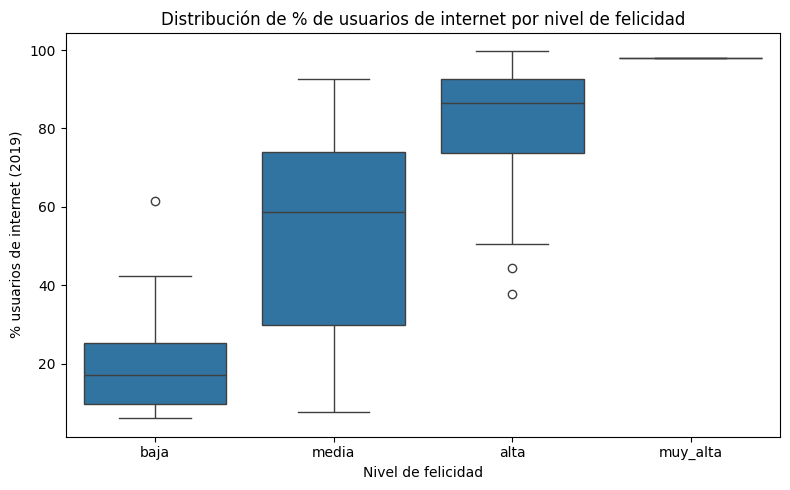

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=full_2019,
    x="happiness_level",
    y="internet_users_pct_2019"
)
plt.title("Distribución de % de usuarios de internet por nivel de felicidad")
plt.xlabel("Nivel de felicidad")
plt.ylabel("% usuarios de internet (2019)")
plt.tight_layout()
plt.show()

### Gráficos de densidad (KDE)

Los gráficos de densidad no sirven para marcar outliers directamente, pero sí ayudan a ver dónde se concentra la mayoría de países. Aquí reviso la forma de la distribución tanto de la puntuación de felicidad como del porcentaje de usuarios de internet.

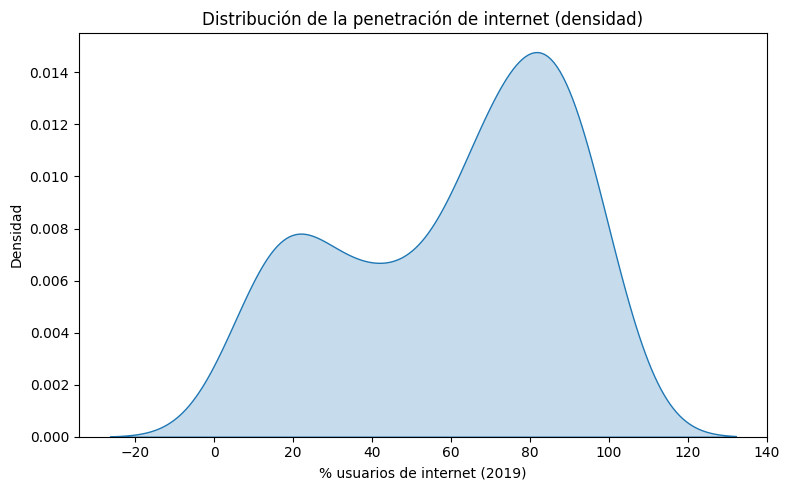

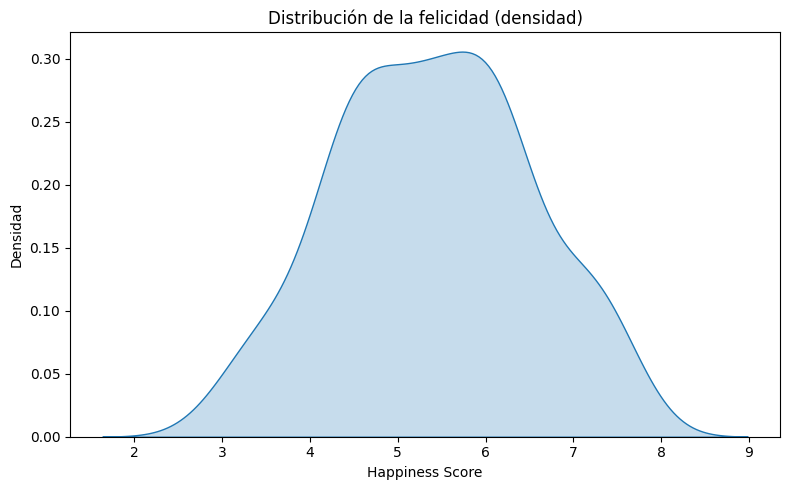

In [27]:
# Densidad de % de usuarios de internet
plt.figure(figsize=(8, 5))
sns.kdeplot(full_2019["internet_users_pct_2019"].dropna(), fill=True)
plt.title("Distribución de la penetración de internet (densidad)")
plt.xlabel("% usuarios de internet (2019)")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Densidad de puntuación de felicidad
plt.figure(figsize=(8, 5))
sns.kdeplot(full_2019["Score"].dropna(), fill=True)
plt.title("Distribución de la felicidad (densidad)")
plt.xlabel("Happiness Score")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

### Interpretación de los outliers por nivel de felicidad

El análisis por niveles de felicidad muestra que los países con **felicidad alta y muy alta** tienden a tener una penetración de internet elevada y relativamente homogénea, con pocos outliers. En cambio, en los grupos de **felicidad baja y media** aparecen más valores atípicos, tanto por exceso como por defecto, lo que sugiere situaciones más desiguales en el acceso digital.

Decido mantener estos outliers en el dataset final porque corresponden a países reales y aportan contexto sobre casos extremos dentro de cada grupo. Más que ruido, los interpreto como señales útiles para futuros análisis sobre bienestar y brecha digital.

### Comparación de valores nulos antes y después de la integración

Aquí comparo el número total de datos faltantes en cada fuente original y en la tabla final integrada.

Nulos en cada fuente original:
 - Happiness (raw): 0
 - Population 2019 (raw): 1
 - Internet 2019 (raw): 47

Nulos en la tabla final integrada: 102


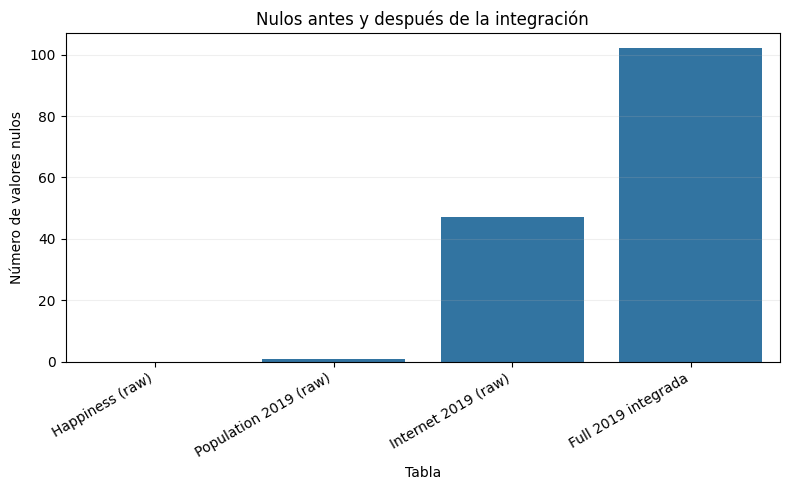

In [31]:
# Meta-análisis de nulos y completitud
nulls_raw = {
    "Happiness (raw)": df_happiness.isna().sum().sum(),
    "Population 2019 (raw)": pop_2019.isna().sum().sum(),
    "Internet 2019 (raw)": internet_2019.isna().sum().sum(),
}

nulls_final = full_2019.isna().sum().sum()

print("Nulos en cada fuente original:")
for k, v in nulls_raw.items():
    print(f" - {k}: {v}")

print(f"\nNulos en la tabla final integrada: {nulls_final}")

# Gráfico comparando nulos antes vs después
labels = list(nulls_raw.keys()) + ["Full 2019 integrada"]
values = list(nulls_raw.values()) + [nulls_final]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=values)
ax.set_ylabel("Número de valores nulos")
ax.set_xlabel("Tabla")
ax.set_title("Nulos antes y después de la integración")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### Exportación del dataset final limpio

In [22]:
# Creo la carpeta 02_processed_data en mi Drive
import os
os.makedirs("/content/drive/MyDrive/02_processed_data", exist_ok=True)

# Guardo la tabla final limpia dentro de la carpeta procesada
full_2019.to_csv(
    "/content/drive/MyDrive/02_processed_data/full_2019_clean.csv",
    index=False
)